In [1]:
import rasterio

In [2]:
import os
import urllib.request
import rasterio
import numpy as np

tile_url = (
    "https://minio.lab.sspcloud.fr/projet-funathon/2026/"
    "project3/data/images/LU000/"
    "2024/4042000_2951690_0_637.tif"
)

with rasterio.open(tile_url) as src:
    tile_crs = src.crs
    tile_bounds = src.bounds
    tile_count = src.count
    tile_height = src.height
    tile_width = src.width
    # Read RGB bands: B4 (Red), B3 (Green), B2 (Blue)
    rgb_data = src.read([4, 3, 2])

print(f"CRS:    {tile_crs}")
print(f"Bounds: {tile_bounds}")
print(f"Shape:  {tile_count} bands x {tile_height} x {tile_width} px")

CRS:    EPSG:3035
Bounds: BoundingBox(left=4042000.0, bottom=2951690.0, right=4044500.0, top=2954190.0)
Shape:  14 bands x 250 x 250 px


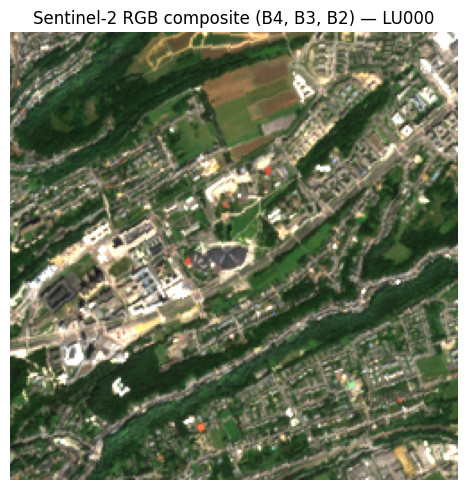

In [3]:
#

import matplotlib.pyplot as plt

# Transpose to (H, W, 3) and normalize for display
rgb = np.transpose(rgb_data, (1, 2, 0)).astype(np.float32)
p98 = np.percentile(rgb, 98)
rgb = np.clip(rgb / p98, 0, 1)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(rgb)
ax.set_title("Sentinel-2 RGB composite (B4, B3, B2) — LU000")
ax.axis("off")
plt.tight_layout()
plt.show()

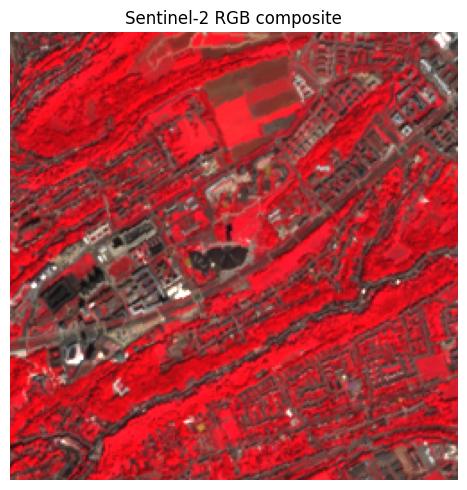

In [11]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

tile_url = (
    "https://minio.lab.sspcloud.fr/projet-funathon/2026/"
    "project3/data/images/LU000/"
    "2024/4042000_2951690_0_637.tif"
)

with rasterio.open(tile_url) as src:
    rgb_data = src.read([8, 4, 3])
    tile_crs = src.crs
    tile_bounds = src.bounds

rgb = np.transpose(rgb_data, (1, 2, 0)).astype(np.float32)
p98 = np.percentile(rgb, 98)
rgb = np.clip(rgb / p98, 0, 1)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(rgb)
ax.set_title("Sentinel-2 RGB composite")
ax.axis("off")
plt.tight_layout()
plt.show()

In [23]:
import requests
import geopandas as gpd
from shapely.geometry import Point

# Step 1: Geocode the city name
response = requests.get(
    "https://nominatim.openstreetmap.org/search",
    params={"q": "46 rue charles quint, Luxembourg", "format": "json", "limit": 1},
    headers={"User-Agent": "funathon-project3"},
)
result = response.json()[0]
lon, lat = float(result["lon"]), float(result["lat"])
print(f"Eurostat coordinates: lon={lon}, lat={lat}")

# Step 2: Create a GeoDataFrame with the point in WGS84, then reproject
city_point = gpd.GeoDataFrame(
    {"city": ["Luxembourg"]}, geometry=[Point(lon, lat)], crs="EPSG:4326"
)
city_point = city_point.to_crs("EPSG:3035")

# Step 3: Load NUTS3 boundaries and spatial join
nuts_url = (
    "https://gisco-services.ec.europa.eu/distribution/v2/"
    "nuts/geojson/NUTS_RG_01M_2021_3035_LEVL_3.geojson"
)
nuts = gpd.read_file(nuts_url)
city_nuts = gpd.sjoin(city_point, nuts, predicate="within")
nuts_code = city_nuts.iloc[0]["NUTS_ID"]
print(f"NUTS3 region: {nuts_code}")  # → LU000

Eurostat coordinates: lon=6.0994796, lat=49.6040938
NUTS3 region: LU000


In [24]:
city_nuts

,city,geometry,index_right,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,CAPT,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM
0,Luxembourg,POINT (4039162.954 2950963.394),1093,LU000,3,LU,Luxembourg,Luxembourg,4,2,3,Luxembourg,Luxembourg,LUX,UN Member State,Luxembourg,T,F,F,Luxemburg


351 tiles in LU000/2024
City point (EPSG:3035): x=4039163, y=2950963
Matching tile: 4037000_2949190_0_660.tif


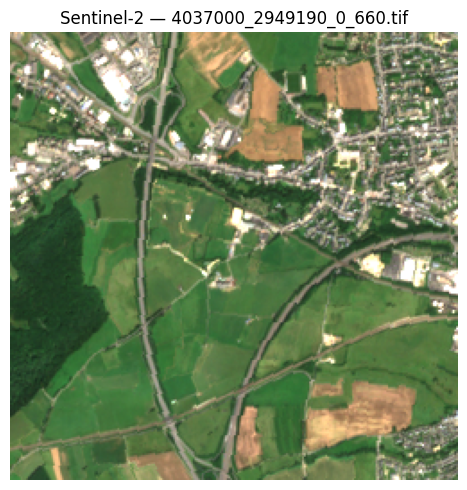

In [25]:
import pandas as pd
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Build the URL to the parquet index
year = 2024
nuts_code = "LU000"
parquet_url = (
    f"https://minio.lab.sspcloud.fr/projet-funathon/2026/"
    f"project3/data/images/{nuts_code}/{year}/filename2bbox.parquet"
)

# Read the tile index
tiles = pd.read_parquet(parquet_url)
print(f"{len(tiles)} tiles in {nuts_code}/{year}")

# Get city coordinates in EPSG:3035
x = city_point.geometry.iloc[0].x
y = city_point.geometry.iloc[0].y
print(f"City point (EPSG:3035): x={x:.0f}, y={y:.0f}")

# Find the tile whose bbox contains the city point
tile_filename = None
for _, row in tiles.iterrows():
    xmin, ymin, xmax, ymax = row["bbox"]
    if xmin <= x <= xmax and ymin <= y <= ymax:
        tile_filename = row["filename"]
        break

print(f"Matching tile: {tile_filename}")

# Build the full HTTPS URL
tile_url = (
    f"https://minio.lab.sspcloud.fr/projet-funathon/2026/"
    f"project3/data/images/{nuts_code}/{year}/{tile_filename}"
)

# Open the tile and display the RGB composite
with rasterio.open(tile_url) as src:
    rgb_data = src.read([4, 3, 2])  # Red, Green, Blue bands
    tile_crs = src.crs
    tile_bounds = src.bounds

rgb = np.transpose(rgb_data, (1, 2, 0)).astype(np.float32)
rgb = np.clip(rgb / np.percentile(rgb, 98), 0, 1)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(rgb)
ax.set_title(f"Sentinel-2 — {tile_filename}")
ax.axis("off")
plt.tight_layout()
plt.show()

In [26]:
tiles

,filename,bbox
0,4034500_3011690_0_34.tif,"[4034500.0, 3011690.0, 4037000.0, 3014190.0]"
1,4034500_3009190_0_59.tif,"[4034500.0, 3009190.0, 4037000.0, 3011690.0]"
2,4037000_3009190_0_60.tif,"[4037000.0, 3009190.0, 4039500.0, 3011690.0]"
3,4039500_3009190_0_61.tif,"[4039500.0, 3009190.0, 4042000.0, 3011690.0]"
4,4029500_3006690_0_82.tif,"[4029500.0, 3006690.0, 4032000.0, 3009190.0]"
...,...,...
346,4029500_2936690_0_782.tif,"[4029500.0, 2936690.0, 4032000.0, 2939190.0]"
347,4032000_2936690_0_783.tif,"[4032000.0, 2936690.0, 4034500.0, 2939190.0]"
348,4034500_2936690_0_784.tif,"[4034500.0, 2936690.0, 4037000.0, 2939190.0]"
349,4037000_2936690_0_785.tif,"[4037000.0, 2936690.0, 4039500.0, 2939190.0]"


WGS84 extent: W=6.0691, S=49.5871, E=6.1054, N=49.6108


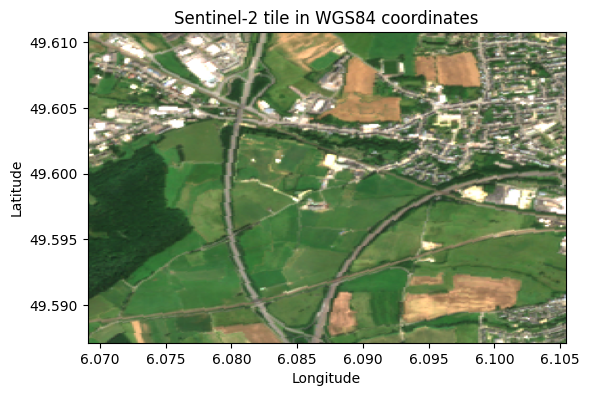

In [27]:
from rasterio.warp import transform_bounds

west, south, east, north = transform_bounds(
    tile_crs, "EPSG:4326", *tile_bounds
)

print(f"WGS84 extent: W={west:.4f}, S={south:.4f}, E={east:.4f}, N={north:.4f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(rgb, extent=[west, east, south, north])
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Sentinel-2 tile in WGS84 coordinates")
plt.tight_layout()
plt.show()

In [34]:
import urllib.request
import io
import numpy as np

# Label URL for a LU000 patch, year 2021
label_url = (
    "https://minio.lab.sspcloud.fr/projet-funathon/2026/"
    "project3/data/labels/LU000/"
    "2021/4037000_2949190_0_660.npy"
)

with urllib.request.urlopen(label_url) as response:
    label_array = np.load(io.BytesIO(response.read()))

print(f"Label shape: {label_array.shape}")
print(f"Data type:   {label_array.dtype}")
print(f"Classes:     {np.unique(label_array)}")

Label shape: (250, 250)
Data type:   uint8
Classes:     [ 1  2  3  5  6  7  9 10]


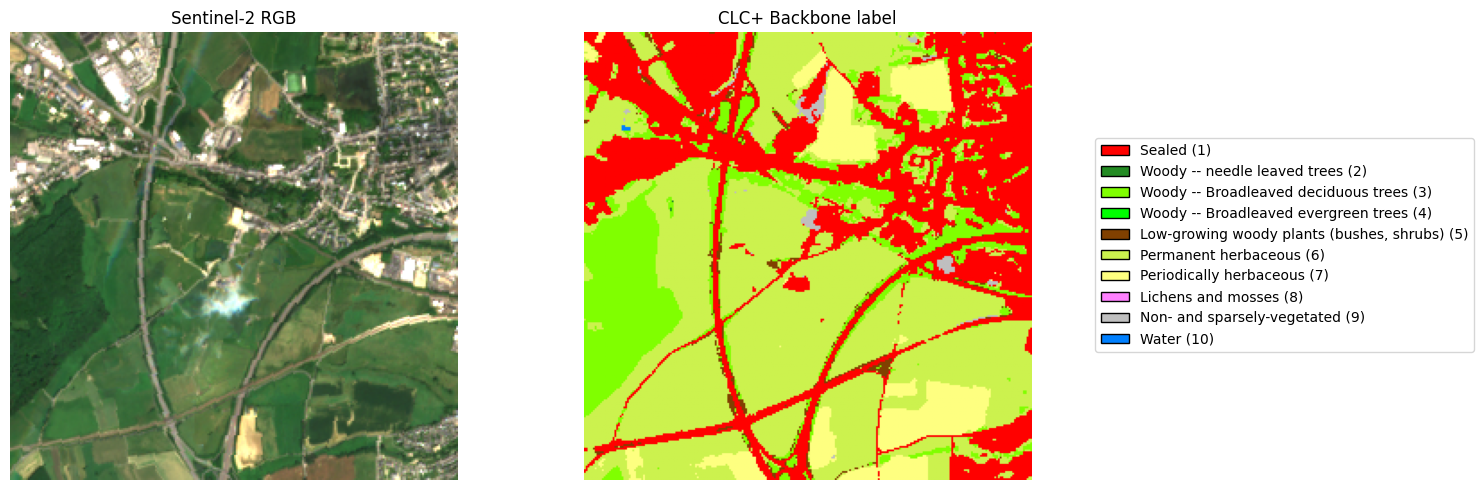

In [35]:
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# CLC+ class names and colours
classes = [
    ("Sealed (1)", "#FF0100"),
    ("Woody -- needle leaved trees (2)", "#238B23"),
    ("Woody -- Broadleaved deciduous trees (3)", "#80FF00"),
    ("Woody -- Broadleaved evergreen trees (4)", "#00FF00"),
    ("Low-growing woody plants (bushes, shrubs) (5)", "#804000"),
    ("Permanent herbaceous (6)", "#CCF24E"),
    ("Periodically herbaceous (7)", "#FEFF80"),
    ("Lichens and mosses (8)", "#FF81FF"),
    ("Non- and sparsely-vegetated (9)", "#BFBFBF"),
    ("Water (10)", "#0080FF"),
]
cmap = ListedColormap([color for _, color in classes])

# Load the matching satellite image
image_url = (
    "https://minio.lab.sspcloud.fr/projet-funathon/2026/"
    "project3/data/images/LU000/"
    "2021/4037000_2949190_0_660.tif"
)
with rasterio.open(image_url) as src:
    rgb_data = src.read([4, 3, 2])

rgb = np.transpose(rgb_data, (1, 2, 0)).astype(np.float32)
rgb = np.clip(rgb / np.percentile(rgb, 98), 0, 1)

# Side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(rgb)
axes[0].set_title("Sentinel-2 RGB")
axes[0].axis("off")

axes[1].imshow(label_array, cmap=cmap, vmin=1, vmax=10)
axes[1].set_title("CLC+ Backbone label")
axes[1].axis("off")

legend_elements = [
    Patch(facecolor=color, edgecolor="black", label=label)
    for label, color in classes
]
fig.legend(
    handles=legend_elements,
    loc="center right",
    bbox_to_anchor=(1.30, 0.5),
    frameon=True,
)
plt.tight_layout()
plt.show()

In [38]:
from transformers import AutoModelForSemanticSegmentation, AutoProcessor
import requests


id2label = requests.get(
    "https://minio.lab.sspcloud.fr/projet-funathon/2026/project3/data/clcplus-backbone-id2label.json"
).json()
id2label = {int(k): v for k, v in id2label.items()}
label2id = {v: k for k, v in id2label.items()}


model_id = "nvidia/mit-b5"
model = AutoModelForSemanticSegmentation.from_pretrained(
    model_id,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

processor = AutoProcessor.from_pretrained(model_id)

[transformers] You passed `num_labels=12` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/1156 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b5
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading fr

In [42]:
print(model)

SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (encoder): SegformerEncoder(
      (patch_embeddings): ModuleList(
        (0): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        )
        (1): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        )
        (2): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(128, 320, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
        )
        (3): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(320, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)

In [45]:
rgb.shape

(250, 250, 3)